In [ ]:
from pathlib import Path
from hydra import initialize, compose
from repo_overview import ParquetDataProcessor
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors



In [ ]:
with initialize(version_base="1.3", config_path="../conf"):
    cfg = compose(config_name="config.yaml", return_hydra_config=True)
    cfg.general.batch_id = "repo_overview"
    cfg.hydra.runtime.cwd = "/home/psa_images/SemiF-AnnotationPipeline"
    cfg.data.database_parquet = (
        "/home/psa_images/SemiF-AnnotationPipeline/repo_overview/database"
    )
    cfg.data.repo_database = "/home/psa_images/SemiF-AnnotationPipeline/repo_overview"

In [ ]:
processor = ParquetDataProcessor(cfg)
processor.read_parquet_file(totals=False)

In [218]:
df = processor.df.copy()
df = df[["EPPO", "USDA_symbol", "is_primary","image_id","batch_id", "cutout_id", "common_name", "general_season"]]
df = df[df["common_name"]!= "Colorchecker"]
df = df[df["common_name"]!= "Unknown"]

## Plot

In [ ]:
image_groupby = df.groupby(["general_season", "common_name"])["image_id"].nunique().reset_index().sort_values(by="image_id", ascending=False)
cutout_groupby = df.groupby(["general_season","common_name","is_primary"])["cutout_id"].nunique().reset_index().sort_values(by="cutout_id", ascending=False)

In [38]:
# Create a base color palette with a distinct color for each column
green = sns.xkcd_palette(["tea"])[0] #(0.0, 0.30197616301422525, 0.12052287581699346)
blue = sns.xkcd_palette(["cool blue"])[0] #(0.03137254901960784, 0.301914648212226, 0.588404459823145)
red = sns.xkcd_palette(["dull red"])[0] #(0.7925720876585928, 0.09328719723183392, 0.11298731257208766)

# Define your base colors for each PlantType. Example:
planttype_colors = {
    "weeds": green,  # Base color for WEEDS
    "cover crops": blue,
    "cash crops": red,  # Base color for CASHCROPS
    # Add more PlantTypes if necessary
}
planttype_colors

{'weeds': (0.396078431372549, 0.6705882352941176, 0.48627450980392156),
 'cover crops': (0.28627450980392155, 0.5176470588235295, 0.7215686274509804),
 'cash crops': (0.7333333333333333, 0.24705882352941178, 0.24705882352941178)}

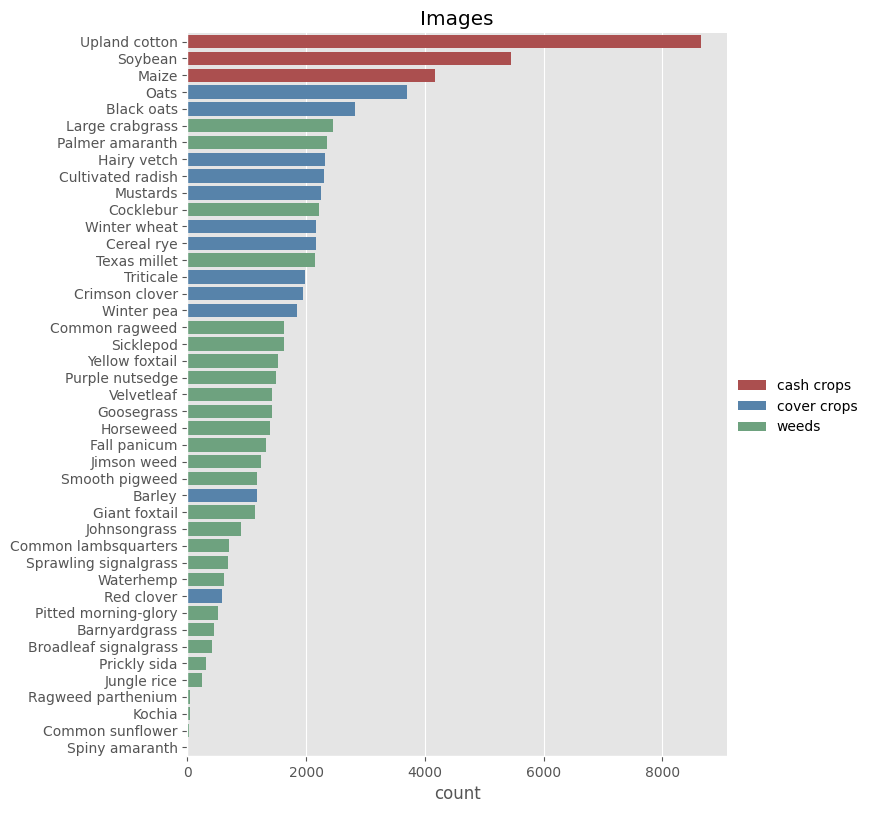

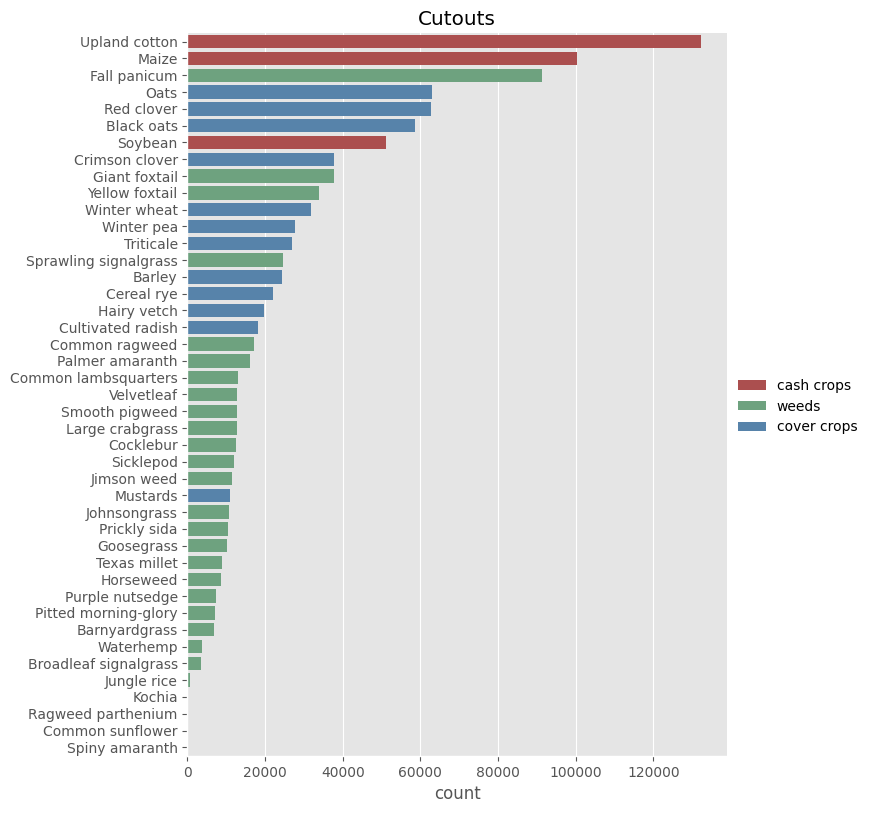

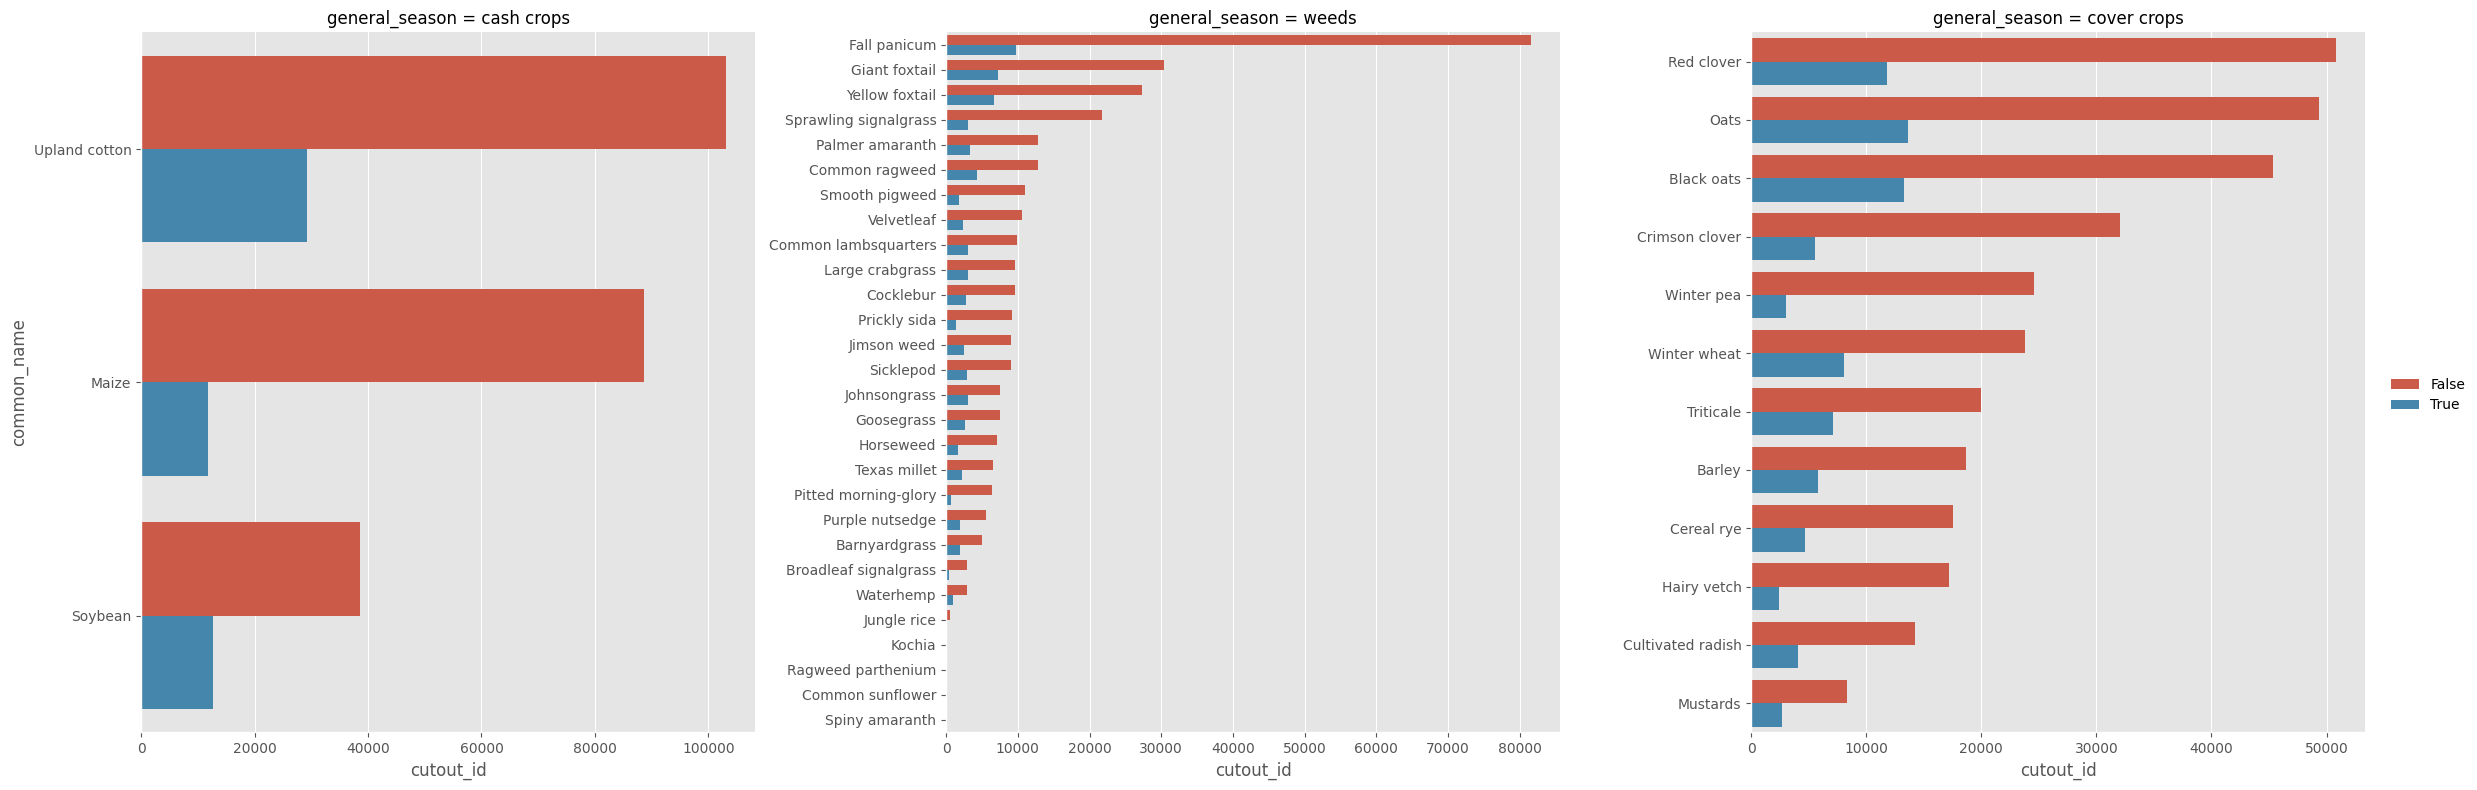

In [36]:
# Plots
style_list = ["fivethirtyeight", "ggplot", "seaborn-v0_8"]
with plt.rc_context({"figure.max_open_warning": len(style_list)}):
    with plt.style.context("ggplot"):
            g = sns.catplot(image_groupby, y="common_name", x="image_id", kind="bar", hue="general_season", height=8, palette=planttype_colors)
            g.set(xlabel="count", ylabel="")
            g._legend.set_title("")
            plt.title("Images")
            plt.show()
            # plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/overall_images.png")

            total_cutout_groupby = cutout_groupby.groupby(["general_season", "common_name"])["cutout_id"].sum().reset_index().sort_values(by="cutout_id", ascending=False)
            g=sns.catplot(total_cutout_groupby, y="common_name", x="cutout_id",hue="general_season",kind="bar", height=8, palette=planttype_colors)
            g.set(xlabel="count", ylabel="")
            g._legend.set_title("")
            plt.title("Cutouts")
            plt.show()


In [66]:
cutout_groupby

,general_season,common_name,is_primary,cutout_id
4,cash crops,Upland cotton,False,103068
0,cash crops,Maize,False,88675
42,weeds,Fall panicum,False,81518
22,cover crops,Red clover,False,50802
20,cover crops,Oats,False,49332
...,...,...,...,...
40,weeds,Common sunflower,False,16
57,weeds,Kochia,True,13
69,weeds,Ragweed parthenium,True,7
41,weeds,Common sunflower,True,2


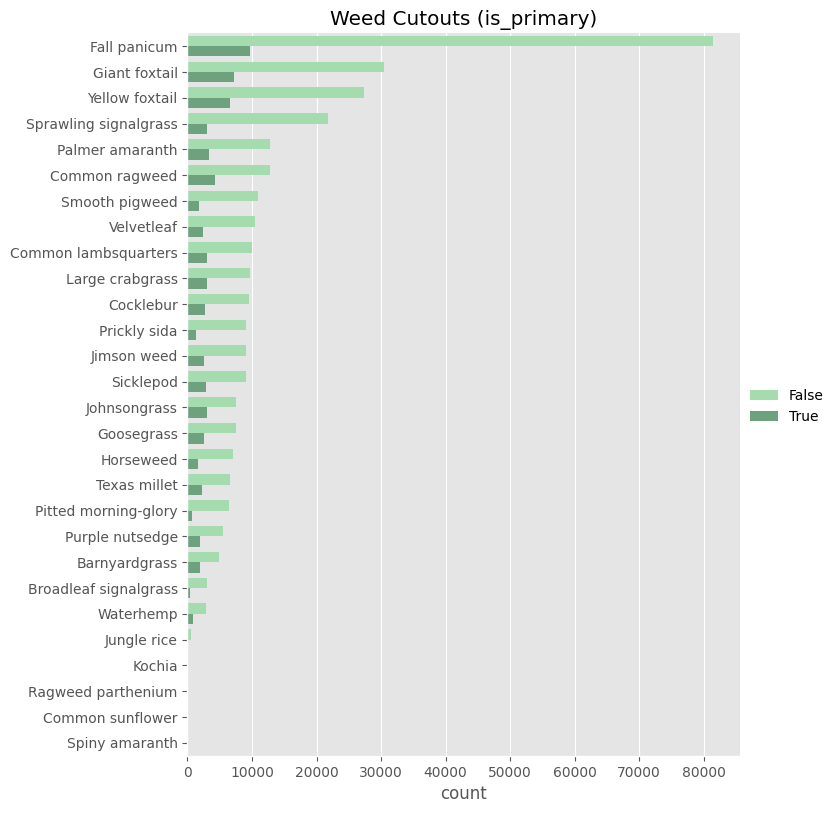

In [181]:
# Create a base color palette with a distinct color for each column
dark_green = sns.xkcd_palette(["tea"])[0] #(0.0, 0.30197616301422525, 0.12052287581699346)
light_green = sns.xkcd_palette(["hospital green"])[0] #(0.0, 0.30197616301422525, 0.12052287581699346)
blue = sns.xkcd_palette(["cool blue"])[0] #(0.03137254901960784, 0.301914648212226, 0.588404459823145)
red = sns.xkcd_palette(["dull red"])[0] #(0.7925720876585928, 0.09328719723183392, 0.11298731257208766)

# Define your base colors for each PlantType. Example:
weed_colors = {
    True: dark_green,  # Base color for WEEDS
    False: light_green,
}

weed_cutout_groupby = cutout_groupby[cutout_groupby["general_season"] == "weeds"]
# Use the custom palette in the catplot
with plt.rc_context({"figure.max_open_warning": len(style_list)}):
     with plt.style.context("ggplot"):
            g=sns.catplot(weed_cutout_groupby, y="common_name", x="cutout_id",hue="is_primary",kind="bar", height=8, sharex=False, sharey=False, palette=weed_colors)#palette=planttype_colors)
            g.set(xlabel="count", ylabel="")
            g._legend.set_title("")
            plt.title("Weed Cutouts (is_primary)")
            plt.show()
    


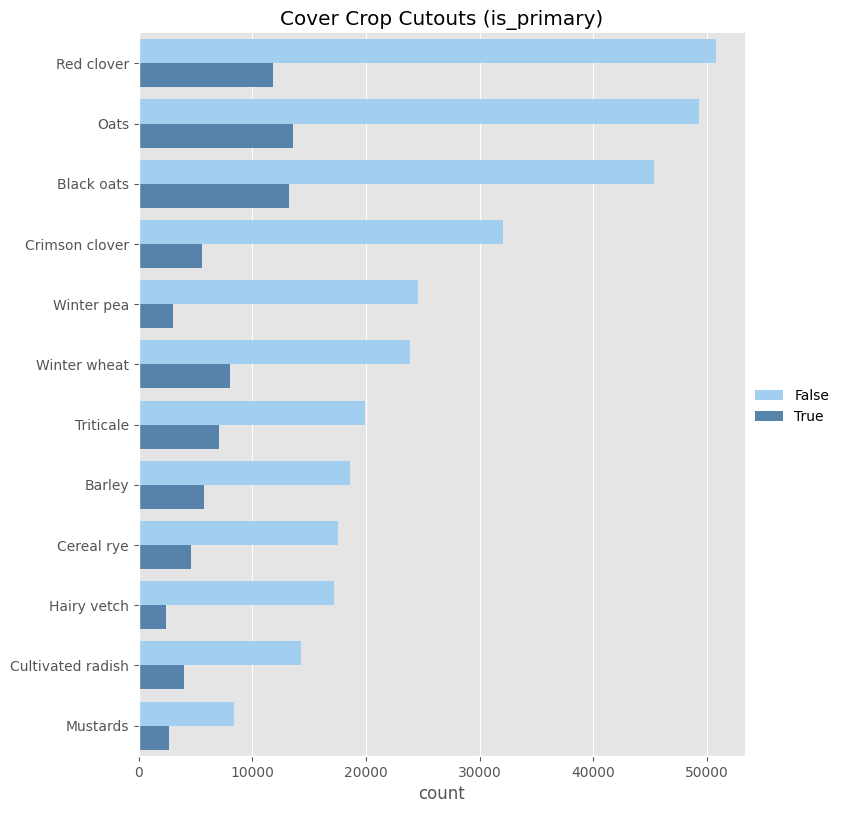

In [184]:
# Create a base color palette with a distinct color for each column
dark_blue = sns.xkcd_palette(["cool blue"])[0] #(0.03137254901960784, 0.301914648212226, 0.588404459823145)
light_blue = sns.xkcd_palette(["light blue"])[0] #(0.03137254901960784, 0.301914648212226, 0.588404459823145)
red = sns.xkcd_palette(["dull red"])[0] #(0.7925720876585928, 0.09328719723183392, 0.11298731257208766)

# Define your base colors for each PlantType. Example:
cover_colors = {
    True: dark_blue,  # Base color for WEEDS
    False: light_blue,
}

cover_cutout_groupby = cutout_groupby[cutout_groupby["general_season"] == "cover crops"]
# Use the custom palette in the catplot
with plt.rc_context({"figure.max_open_warning": len(style_list)}):
     with plt.style.context("ggplot"):
            g=sns.catplot(cover_cutout_groupby, 
                          y="common_name", 
                          x="cutout_id",
                          hue="is_primary",
                          kind="bar", 
                          height=8, 
                          palette=cover_colors,
                        #   hue_order=[True, False],
                          )
            g.set(xlabel="count", ylabel="")
            g._legend.set_title("")
            plt.title("Cover Crop Cutouts (is_primary)")
            plt.show()
    


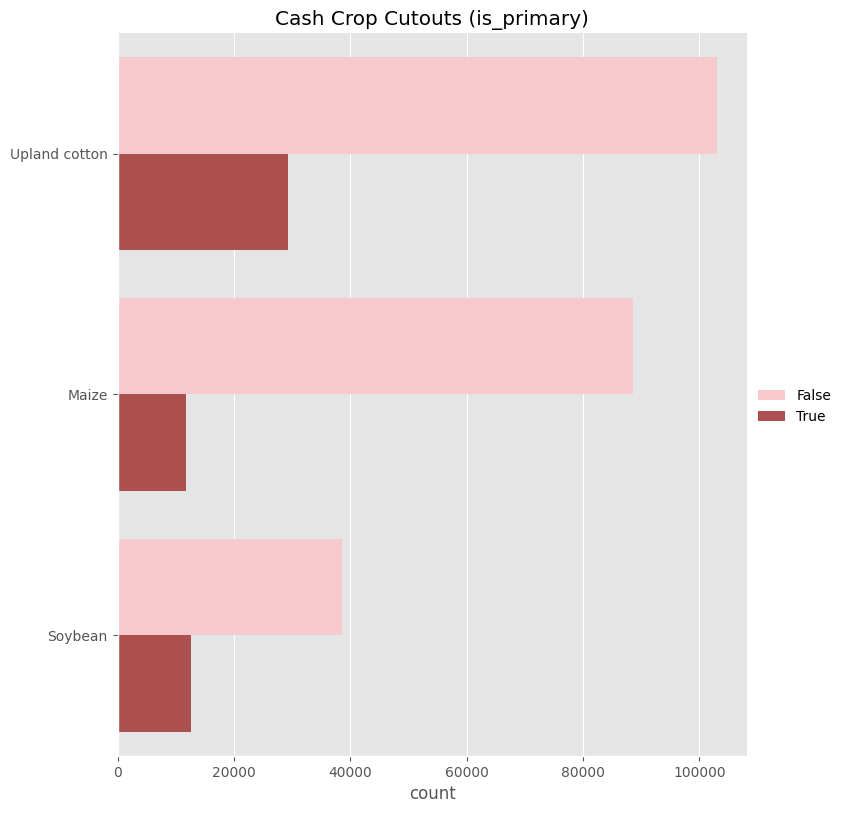

In [185]:
# Create a base color palette with a distinct color for each column
dark_red = sns.xkcd_palette(["dull red"])[0] #(0.7925720876585928, 0.09328719723183392, 0.11298731257208766)
light_red = sns.xkcd_palette(["pale rose"])[0] #(0.7925720876585928, 0.09328719723183392, 0.11298731257208766)

# Define your base colors for each PlantType. Example:
cover_colors = {
    True: dark_red,  # Base color for WEEDS
    False: light_red,
}

cash_cutout_groupby = cutout_groupby[cutout_groupby["general_season"] == "cash crops"]
# Use the custom palette in the catplot
with plt.rc_context({"figure.max_open_warning": len(style_list)}):
     with plt.style.context("ggplot"):
            g=sns.catplot(cash_cutout_groupby, 
                          y="common_name", 
                          x="cutout_id",
                          hue="is_primary",
                          kind="bar", 
                          height=8, 
                          palette=cover_colors,
                        #   hue_order=[True, False],
                          )
            g.set(xlabel="count", ylabel="")
            g._legend.set_title("")
            plt.title("Cash Crop Cutouts (is_primary)")
            plt.show()
    


In [204]:
imgs = df.groupby(["EPPO", "general_season", "common_name"])["image_id"].nunique().reset_index().sort_values(by=["general_season", "image_id"], ascending=[False,False])
cuts = df.groupby(["EPPO", "general_season", "common_name"])["cutout_id"].nunique().reset_index().sort_values(by=["general_season", "cutout_id"], ascending=[False,False])
pd.merge(imgs, cuts, how="left", on=["common_name", "general_season", "EPPO"]).sort_values(by=["general_season", "image_id"], ascending=[False,False])
# imgs
# cuts

,EPPO,general_season,common_name,image_id,cutout_id
0,DIGSA,weeds,Large crabgrass,2452,12735
1,AMAPA,weeds,Palmer amaranth,2355,16163
2,XANST,weeds,Cocklebur,2224,12387
3,PANTE,weeds,Texas millet,2152,8766
4,AMBEL,weeds,Common ragweed,1626,17096
5,CASOB,weeds,Sicklepod,1621,11893
6,SETPU,weeds,Yellow foxtail,1531,33944
7,CYPRO,weeds,Purple nutsedge,1485,7401
8,ABUTH,weeds,Velvetleaf,1429,12848
9,ELEIN,weeds,Goosegrass,1418,10115


In [219]:
# df[df["is_primary"]==True]
# df[df["general_season"]=="cash crops"].common_name.nunique()
df.batch_id.nunique()

175